In [ ]:
pip install gurobi

ERROR: Could not find a version that satisfies the requirement gurobi (from versions: none)
ERROR: No matching distribution found for gurobi


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
rnd = np.random
rnd.seed(4)

In [ ]:
import pandas as pd

In [ ]:
dataset = pd.read_excel('/content/OK 18 new2. VRP.xlsx')

In [ ]:
dataset

,Unnamed: 0,route 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,route 2,Unnamed: 8,Unnamed: 9,...,Unnamed: 24,route 5,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33
0,NaN,C0,C1,C2,C3,C4,C5,C0,C1,C2,...,C5,C0,C1,C2,C3,C4,C5,NaN,NaN,NaN
1,C0,0,18,25,12,40,20,0,25,15,...,35,0,22,18,30,10,38,NaN,NaN,NaN
2,C1,18,0,38,27,5,48,25,0,37,...,18,22,0,16,38,9,18,NaN,NaN,NaN
3,C2,25,38,0,43,37,6,15,37,0,...,28,18,16,0,10,36,30,NaN,NaN,NaN
4,C3,12,27,43,0,8,45,30,8,42,...,16,30,38,10,0,24,18,NaN,NaN,NaN
5,C4,40,5,37,8,0,39,9,44,23,...,42,10,9,36,24,0,40,NaN,NaN,NaN
6,C5,20,48,6,45,39,0,40,13,47,...,0,38,18,30,18,40,0,NaN,NaN,NaN
7,Capacity,NaN,50,NaN,NaN,NaN,NaN,50,NaN,NaN,...,NaN,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,DEMAND,0,23,8,12,8,10,0,25,18,...,11,0,16,8,10,10,8,NaN,NaN,NaN
9,time,0,20,30,20,10,45,0,50,30,...,20,0,20,30,40,60,30,NaN,300.0,MAX TIME


In [ ]:
n = 20 # number of clients
m = 5 # jumlah kurir
xc = rnd.rand(n+1)*200
yc = rnd.rand(n+1)*100

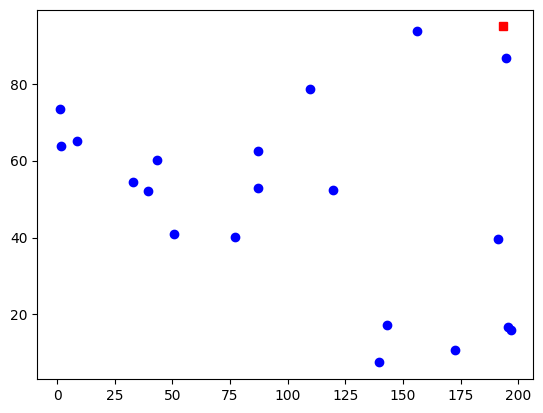

In [ ]:
plt.plot(xc[0],yc[0],c='r',marker='s')
plt.scatter(xc[1:],yc[1:],c='b')

Tujuan yang ingin dicapai adalah meminimumkan biaya. Kemudian meningkatkan atau menurunkan konstrain atau fungsi kendala, sehingga kapasitasnya bisa dimaksimalkan dengan biaya yang minimum.

In [ ]:
N = [i for i in range(1,n+1)] # Nomor klien
V = [0] + N # Nomor simpul
A = [(i,j) for i in V for j in V if i!=j] # Nomor jalur
D = {(i,j): np.hypot(xc[i]-xc[j],yc[i]-yc[j]) for i,j in A} # Biaya
U = 20 # Jumlah kapasitas kendaraan
q = {i: rnd.randint(1,20) for i in N} # Jumlah barang yang harus diantar
                                      #untuk pelanggan ke-i
K = [k for k in range(1,m+1)] # Nomor kurir
Ut = 10 # menit
t = {(i,j,k): rnd.randint(1,10) for i,j in A for k in K}
St = 10 #menit
st = {i: rnd.randint(1,10) for i in N} # Jumlah waktu pelayanan untuk pelanggan ke-i
Vl = 30 #km/h
vl = {k: rnd.randint(20,30) for k in K}

In [ ]:
pip install gurobipy

In [ ]:
from gurobipy import Model, GRB, quicksum

In [ ]:
mdl = Model('VRP')

In [ ]:
x = mdl.addVars(A,K, vtype=GRB.BINARY)
u = mdl.addVars(N, vtype = GRB.CONTINUOUS)

In [ ]:
mdl.modelSense = GRB.MINIMIZE
mdl.setObjective(quicksum(x[i,j,k]*D[i,j] for i,j in A for k in K))

In [ ]:
mdl.addConstrs(quicksum(x[i, j, k] for j in V for k in K if j != i) == 1 for i in N)
mdl.addConstrs(quicksum(x[i, j, k] for i in V for k in K if i != j) == 1 for j in N)
mdl.addConstrs((x[i, j, k] == 1) >> (u[i] + q[i] == u[j]) for i, j in A for k in K if i != 0 and j != 0)
mdl.addConstrs(u[i] >= q[i] for i in N)
mdl.addConstrs(u[i] <= U for i in N)
mdl.addConstrs(quicksum(t[i,j,k]*x[i, j, k] for i,j in A for k in K) <= Ut for i,j in A for k in K)
mdl.addConstrs(quicksum(vl[k]*x[i, j, k] for i,j in A for k in K)<= Vl for i,j in A for k in K)
mdl.addConstrs(st[l]*x[i,j,k] <= St for l in N for i,j in A for k in K)

{1: <gurobi.Constr *Awaiting Model Update*>,
 2: <gurobi.Constr *Awaiting Model Update*>,
 3: <gurobi.Constr *Awaiting Model Update*>,
 4: <gurobi.Constr *Awaiting Model Update*>,
 5: <gurobi.Constr *Awaiting Model Update*>,
 6: <gurobi.Constr *Awaiting Model Update*>,
 7: <gurobi.Constr *Awaiting Model Update*>,
 8: <gurobi.Constr *Awaiting Model Update*>,
 9: <gurobi.Constr *Awaiting Model Update*>,
 10: <gurobi.Constr *Awaiting Model Update*>,
 11: <gurobi.Constr *Awaiting Model Update*>,
 12: <gurobi.Constr *Awaiting Model Update*>,
 13: <gurobi.Constr *Awaiting Model Update*>,
 14: <gurobi.Constr *Awaiting Model Update*>,
 15: <gurobi.Constr *Awaiting Model Update*>,
 16: <gurobi.Constr *Awaiting Model Update*>,
 17: <gurobi.Constr *Awaiting Model Update*>,
 18: <gurobi.Constr *Awaiting Model Update*>,
 19: <gurobi.Constr *Awaiting Model Update*>,
 20: <gurobi.Constr *Awaiting Model Update*>}

In [ ]:
mdl.optimize()

Gurobi Optimizer version 11.0.0 build v11.0.0rc2 (linux64 - "Ubuntu 22.04.3 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads



GurobiError: Model too large for size-limited license; visit https://www.gurobi.com/free-trial for a full license

In [ ]:
active_arcs = [a for a in A if x[a].x>0.99]

In [ ]:
active_arcs

In [ ]:
for i,j in active_arcs:
  plt.plot([xc[i],xc[j]],[yc[i],yc[j]],c='g',zorder=0)
plt.plot(xc[0],yc[0],c='r',marker='s')
plt.scatter(xc[1:],yc[1:],c='b')